# Does cleaning improve agreement beyond reducing the sample size?

Cleaning leaves fewer cross-assay comparisons. Better agreement could therefore reflect either the quality flags or ordinary variation from using a smaller sample.

For each Case Study 2/3 dataset, this notebook:

1. builds a **baseline** set and a strictly nested **cleaned** set;
2. randomly retains the cleaned number of comparisons from the baseline, without replacement;
3. repeats this 5,000 times; and
4. compares the observed cleaned result with the random 95% range.

A second check preserves the cleaned counts within each CYP target/readout task or Caco-2 assay pair. Coverage counts show what remains after cleaning. Random retention is used instead of bootstrap sampling with replacement because cleaning deletes observed comparisons rather than duplicating them.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from scipy import stats

from Capricho.analysis import DroppingComment, explode_assay_comparability, r2_score
from Capricho.core.pandas_helper import filter_dropping_flags
from Capricho.logger import logger

logger.disable("Capricho")  # Keep the notebook output focused on the analysis.

NOTEBOOK_DIR = Path.cwd()
if NOTEBOOK_DIR.name != "notebooks":
    NOTEBOOK_DIR = NOTEBOOK_DIR / "notebooks"

N_RESAMPLES = 5_000
SEED = 20260731

DATASETS = [
    {
        "name": "CYP inhibition",
        "path": NOTEBOOK_DIR / "data/cyp/cyp_chembl_data-chembl36.csv",
        "value": "pchembl_value",
        "multiassay": "processed_smiles",
        "baseline_flags": [
            DroppingComment.DATA_VALIDITY_COMMENT.value,
            DroppingComment.POTENTIAL_DUPLICATE.value,
        ],
        "cleaning_flags": [
            DroppingComment.UNIT_ANNOTATION_ERROR.value,
            DroppingComment.UNDEFINED_STEREOCHEMISTRY.value,
            DroppingComment.ASSAY_SIZE_TOO_SMALL.value,
        ],
        "composition": "task",
        "log_transform": False,
    },
    {
        "name": "Caco-2 A→B",
        "path": NOTEBOOK_DIR / "data/caco2/caco2_a_to_b-chembl36.csv",
        "value": "standard_value",
        "multiassay": "assay_chembl_id",
        "baseline_flags": [DroppingComment.DATA_VALIDITY_COMMENT.value],
        "cleaning_flags": [DroppingComment.UNDEFINED_STEREOCHEMISTRY.value],
        "composition": "assay_pair",
        "log_transform": True,
    },
    {
        "name": "Caco-2 B→A",
        "path": NOTEBOOK_DIR / "data/caco2/caco2_b_to_a-chembl36.csv",
        "value": "standard_value",
        "multiassay": "assay_chembl_id",
        "baseline_flags": [DroppingComment.DATA_VALIDITY_COMMENT.value],
        "cleaning_flags": [DroppingComment.UNDEFINED_STEREOCHEMISTRY.value],
        "composition": "assay_pair",
        "log_transform": True,
    },
]

## 1. Build comparable before-and-after datasets

Each row below compares two assays for the same aggregated datapoint. The additional cleaning flags are applied **to the baseline**, ensuring that every cleaned comparison was present before cleaning.

In [2]:
def joined_label(frame, columns):
    if not columns:
        return pd.Series("all", index=frame.index, dtype="string")
    return frame[columns].astype("string").fillna("<missing>").agg(" | ".join, axis=1)


def assay_pair_label(frame):
    left = frame["assay_chembl_id_x"].astype("string").fillna("<missing>")
    right = frame["assay_chembl_id_y"].astype("string").fillna("<missing>")
    return pd.Series(
        np.where(left <= right, left.str.cat(right, sep=" ↔ "), right.str.cat(left, sep=" ↔ ")),
        index=frame.index,
        dtype="string",
    )


def build_comparisons(config):
    data = pd.read_csv(config["path"], engine="pyarrow")
    multiassay = data[
        data[config["multiassay"]].astype("string").str.contains("|", regex=False, na=False)
    ].copy()
    multiassay["source_datapoint_id"] = np.arange(len(multiassay))

    pairs = explode_assay_comparability(
        multiassay,
        sep_str="|",
        value_column=config["value"],
    )
    x_column, y_column = f"{config['value']}_x", f"{config['value']}_y"
    pairs = pairs[
        pd.to_numeric(pairs[x_column], errors="coerce") != pd.to_numeric(pairs[y_column], errors="coerce")
    ].reset_index(drop=True)
    pairs["comparison_id"] = np.arange(len(pairs))

    x = pd.to_numeric(pairs[x_column], errors="raise").to_numpy(dtype=float)
    y = pd.to_numeric(pairs[y_column], errors="raise").to_numpy(dtype=float)
    if config["log_transform"]:
        # Match the log scale used in the Case Study 3 comparability plots.
        x = -np.log10(x + 0.001) + 6
        y = -np.log10(y + 0.001) + 6
    pairs["analysis_x"], pairs["analysis_y"] = x, y

    pairs["task"] = joined_label(
        pairs,
        ["target_chembl_id", "standard_type"] if config["composition"] == "task" else [],
    )
    pairs["assay_pair"] = assay_pair_label(pairs)
    pairs["composition_group"] = pairs[config["composition"]]

    baseline = filter_dropping_flags(pairs, config["baseline_flags"], column="dropping_comment").reset_index(
        drop=True
    )
    cleaned = filter_dropping_flags(
        baseline, config["cleaning_flags"], column="dropping_comment"
    ).reset_index(drop=True)

    assert set(cleaned["comparison_id"]).issubset(baseline["comparison_id"])
    return baseline, cleaned


comparisons = {config["name"]: build_comparisons(config) for config in DATASETS}

sample_sizes = pd.DataFrame(
    [
        {
            "Dataset": name,
            "Baseline comparisons": len(baseline),
            "Cleaned comparisons": len(cleaned),
            "Retained": f"{len(cleaned) / len(baseline):.1%}",
        }
        for name, (baseline, cleaned) in comparisons.items()
    ]
)
display(sample_sizes)

,Dataset,Baseline comparisons,Cleaned comparisons,Retained
0,CYP inhibition,7988,2337,29.3%
1,Caco-2 A→B,172,60,34.9%
2,Caco-2 B→A,173,59,34.1%


## 2. Compare cleaning with random retention

Four measures match the manuscript figure. Higher values are favorable for Spearman ρ, Kendall τ, and CAPRICHO's identity-line R²; a lower percentage of pairs more than one log unit apart is favorable.

The empirical one-sided probability is the fraction of random subsets performing at least as well as the cleaned set, with a plus-one correction. It is a sensitivity diagnostic rather than a standalone inferential test because comparisons sharing a compound are not fully independent.

In [3]:
METRICS = {
    "spearman_rho": ("Spearman ρ", True),
    "kendall_tau": ("Kendall τ", True),
    "r2": ("R²", True),
    "outside_1_pct": ("Pairs >1 log unit apart (%)", False),
}


def agreement_values(x, y):
    difference = np.abs(x - y)
    return {
        "spearman_rho": stats.spearmanr(x, y).statistic,
        "kendall_tau": stats.kendalltau(x, y).statistic,
        "r2": r2_score(x, y),
        "outside_1_pct": np.mean(difference > 1) * 100,
    }


def agreement(frame):
    return agreement_values(
        frame["analysis_x"].to_numpy(dtype=float),
        frame["analysis_y"].to_numpy(dtype=float),
    )


def random_retention(baseline, cleaned, rng, strata=None):
    # Return metric distributions for random subsets with the cleaned sample size.
    x = baseline["analysis_x"].to_numpy(dtype=float)
    y = baseline["analysis_y"].to_numpy(dtype=float)
    draws = {metric: np.empty(N_RESAMPLES) for metric in METRICS}

    if strata is None:
        pools = None
    else:
        baseline_groups = baseline.groupby(strata, sort=True).indices
        cleaned_counts = cleaned.groupby(strata, sort=True).size()
        pools = [(np.asarray(baseline_groups[group]), int(size)) for group, size in cleaned_counts.items()]

    for draw in range(N_RESAMPLES):
        if pools is None:
            indices = rng.choice(len(baseline), len(cleaned), replace=False)
        else:
            indices = np.concatenate([rng.choice(pool, size, replace=False) for pool, size in pools])
        for metric, value in agreement_values(x[indices], y[indices]).items():
            draws[metric][draw] = value
    return draws


def summarize_null(dataset, design, baseline, cleaned, draws):
    before, after = agreement(baseline), agreement(cleaned)
    rows = []
    for metric, (label, higher_is_better) in METRICS.items():
        random_values = draws[metric]
        observed = after[metric]
        as_good = random_values >= observed if higher_is_better else random_values <= observed
        rows.append(
            {
                "dataset": dataset,
                "design": design,
                "metric": metric,
                "metric_label": label,
                "n_before": len(baseline),
                "n_after": len(cleaned),
                "before": before[metric],
                "after": observed,
                "random_low": np.quantile(random_values, 0.025),
                "random_median": np.quantile(random_values, 0.5),
                "random_high": np.quantile(random_values, 0.975),
                "empirical_probability": (as_good.sum() + 1) / (N_RESAMPLES + 1),
            }
        )
    return rows


seeds = iter(np.random.SeedSequence(SEED).spawn(len(DATASETS) * 2))
records = []
for config in DATASETS:
    name = config["name"]
    baseline, cleaned = comparisons[name]

    size_matched = random_retention(baseline, cleaned, np.random.default_rng(next(seeds)))
    records += summarize_null(name, "Size matched", baseline, cleaned, size_matched)

    composition_matched = random_retention(
        baseline,
        cleaned,
        np.random.default_rng(next(seeds)),
        strata="composition_group",
    )
    design = "Task matched" if config["composition"] == "task" else "Assay-pair matched"
    records += summarize_null(name, design, baseline, cleaned, composition_matched)

results = pd.DataFrame(records)

In [4]:
def result_table(frame, include_before=True):
    table = frame.copy()
    table["Random 95% range"] = table.apply(lambda row: f"{row.random_low:.3f}–{row.random_high:.3f}", axis=1)
    table["Random subsets as good or better"] = table["empirical_probability"].map(
        lambda value: f"{value:.2%}"
    )
    columns = ["dataset", "metric_label"]
    if include_before:
        table["Comparisons"] = table.apply(lambda row: f"{row.n_before:,} → {row.n_after:,}", axis=1)
        columns += ["Comparisons", "before"]
    columns += ["after", "Random 95% range", "Random subsets as good or better"]
    return table[columns].rename(
        columns={
            "dataset": "Dataset",
            "metric_label": "Metric",
            "before": "Before",
            "after": "After",
        }
    )


print("Random removal matched only on sample size")
display(result_table(results.query("design == 'Size matched'")).round(3))

print("Random removal also matched on retained task or assay-pair composition")
display(result_table(results.query("design != 'Size matched'"), include_before=False).round(3))

Random removal matched only on sample size


,Dataset,Metric,Comparisons,Before,After,Random 95% range,Random subsets as good or better
0,CYP inhibition,Spearman ρ,"7,988 → 2,337",0.625,0.733,0.600–0.650,0.02%
1,CYP inhibition,Kendall τ,"7,988 → 2,337",0.460,0.560,0.441–0.480,0.02%
2,CYP inhibition,R²,"7,988 → 2,337",0.248,0.546,0.194–0.300,0.02%
3,CYP inhibition,Pairs >1 log unit apart (%),"7,988 → 2,337",25.951,11.596,24.390–27.471,0.02%
8,Caco-2 A→B,Spearman ρ,172 → 60,0.689,0.826,0.536–0.803,0.86%
9,Caco-2 A→B,Kendall τ,172 → 60,0.514,0.638,0.393–0.624,1.32%
10,Caco-2 A→B,R²,172 → 60,0.331,0.485,0.003–0.510,5.10%
11,Caco-2 A→B,Pairs >1 log unit apart (%),172 → 60,1.744,3.333,0.000–5.000,95.38%
16,Caco-2 B→A,Spearman ρ,173 → 59,0.677,0.747,0.531–0.785,11.12%
17,Caco-2 B→A,Kendall τ,173 → 59,0.496,0.566,0.380–0.601,10.34%


Random removal also matched on retained task or assay-pair composition


,Dataset,Metric,After,Random 95% range,Random subsets as good or better
4,CYP inhibition,Spearman ρ,0.733,0.674–0.718,0.02%
5,CYP inhibition,Kendall τ,0.560,0.515–0.549,0.08%
6,CYP inhibition,R²,0.546,0.356–0.449,0.02%
7,CYP inhibition,Pairs >1 log unit apart (%),11.596,16.645–18.913,0.02%
12,Caco-2 A→B,Spearman ρ,0.826,0.579–0.802,0.44%
13,Caco-2 A→B,Kendall τ,0.638,0.415–0.614,0.64%
14,Caco-2 A→B,R²,0.485,-0.077–0.425,0.24%
15,Caco-2 A→B,Pairs >1 log unit apart (%),3.333,0.000–5.000,95.36%
20,Caco-2 B→A,Spearman ρ,0.747,0.522–0.771,7.86%
21,Caco-2 B→A,Kendall τ,0.566,0.371–0.586,6.54%


## 3. Report retained coverage

Agreement is only one side of the trade-off. These counts make the accompanying loss of compounds, assays, targets, tasks, and assay-pair coverage explicit. They do not establish chemical-space representativeness, which would require a separate structure-based analysis.

In [5]:
def unique_assays(frame):
    assays = pd.concat(
        [frame["assay_chembl_id_x"], frame["assay_chembl_id_y"]],
        ignore_index=True,
    )
    return assays.dropna().nunique()


def coverage_counts(frame):
    return {
        "Comparisons": len(frame),
        "Compounds": frame["connectivity"].dropna().nunique(),
        "Aggregated datapoints": frame["source_datapoint_id"].nunique(),
        "Assays": unique_assays(frame),
        "Targets": frame["target_chembl_id"].dropna().nunique(),
        "Tasks": frame["task"].nunique(),
        "Assay pairs": frame["assay_pair"].nunique(),
    }


coverage_rows = []
for name, (baseline, cleaned) in comparisons.items():
    before, after = coverage_counts(baseline), coverage_counts(cleaned)
    coverage_rows.append(
        {"Dataset": name} | {measure: f"{before[measure]:,} → {after[measure]:,}" for measure in before}
    )

coverage = pd.DataFrame(coverage_rows)
display(coverage)

,Dataset,Comparisons,Compounds,Aggregated datapoints,Assays,Targets,Tasks,Assay pairs
0,CYP inhibition,"7,988 → 2,337","1,419 → 943","1,705 → 1,090","1,263 → 372",13 → 10,28 → 18,"4,571 → 528"
1,Caco-2 A→B,172 → 60,63 → 19,63 → 19,8 → 5,2 → 1,1 → 1,13 → 10
2,Caco-2 B→A,173 → 59,65 → 20,65 → 20,6 → 4,2 → 1,1 → 1,7 → 6


## 4. Visual summary

The gray × is the full baseline, the blue dot and line are the median and 95% range after random size-matched retention, and the green diamond is the actual cleaned result. Marker shape as well as color identifies each role.

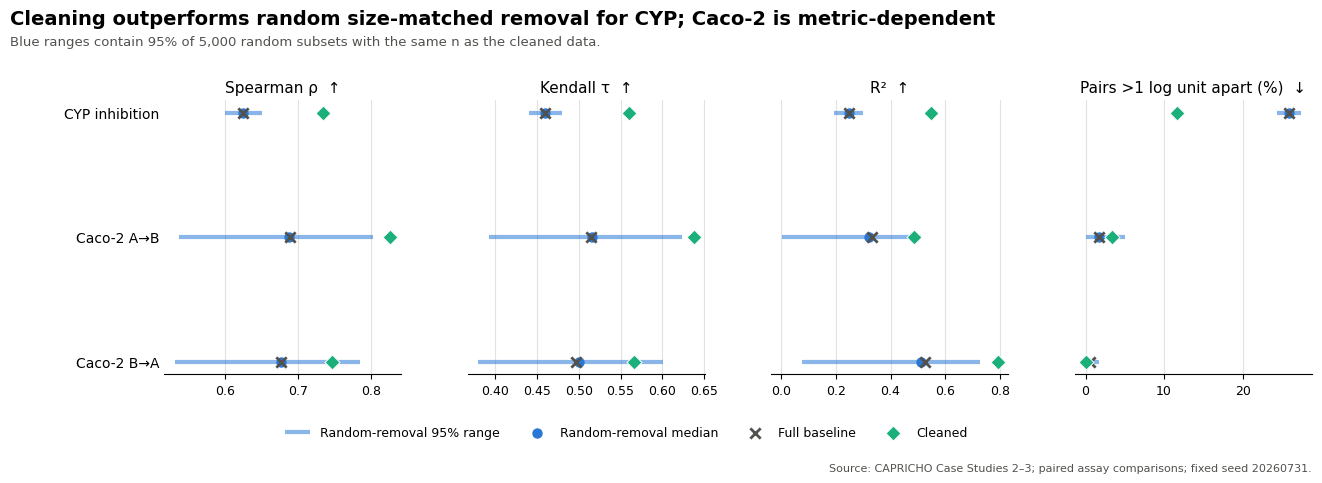

In [6]:
shown = results.query("design == 'Size matched'")
dataset_order = [config["name"] for config in DATASETS]
metric_order = list(METRICS)
y_positions = np.arange(len(dataset_order))[::-1]

fig, axes = plt.subplots(1, 4, figsize=(14, 4.8), sharey=True)
for axis, metric in zip(axes, metric_order):
    panel = shown.query("metric == @metric").set_index("dataset").loc[dataset_order]
    axis.hlines(
        y_positions,
        panel["random_low"],
        panel["random_high"],
        color="#2a78d6",
        linewidth=3,
        alpha=0.55,
        label="Random-removal 95% range",
    )
    axis.scatter(
        panel["random_median"],
        y_positions,
        color="#2a78d6",
        s=42,
        label="Random-removal median",
        zorder=2,
    )
    axis.scatter(
        panel["before"],
        y_positions,
        color="#52514e",
        marker="x",
        s=55,
        linewidth=2,
        label="Full baseline",
        zorder=3,
    )
    axis.scatter(
        panel["after"],
        y_positions,
        color="#1baf7a",
        marker="D",
        s=58,
        edgecolor="white",
        linewidth=0.7,
        label="Cleaned",
        zorder=4,
    )
    label, higher_is_better = METRICS[metric]
    axis.set_title(f"{label}  {'↑' if higher_is_better else '↓'}", fontsize=11)
    axis.grid(axis="x", color="#e2e2df", linewidth=0.8)
    axis.set_axisbelow(True)
    axis.spines[["top", "right", "left"]].set_visible(False)
    axis.tick_params(axis="y", length=0)
    axis.tick_params(axis="x", labelsize=9)

axes[0].set_yticks(y_positions, dataset_order, fontsize=10)
fig.suptitle(
    "Cleaning outperforms random size-matched removal for CYP; Caco-2 is metric-dependent",
    x=0.06,
    ha="left",
    fontsize=14,
    fontweight="bold",
)
fig.text(
    0.06,
    0.905,
    "Blue ranges contain 95% of 5,000 random subsets with the same n as the cleaned data.",
    ha="left",
    fontsize=9.5,
    color="#52514e",
)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.06),
    ncol=4,
    frameon=False,
    fontsize=9,
)
fig.text(
    0.99,
    0.018,
    "Source: CAPRICHO Case Studies 2–3; paired assay comparisons; fixed seed 20260731.",
    ha="right",
    fontsize=8,
    color="#52514e",
)
fig.subplots_adjust(left=0.17, right=0.99, top=0.79, bottom=0.22, wspace=0.28)
plt.show()

## Interpretation

- **CYP inhibition:** all four cleaned statistics lie beyond the random size-matched range in the favorable direction. Reduced sample size alone does not explain the improvement.
- **Caco-2 A→B:** rank agreement improves beyond random removal. R² is borderline under size-only matching, and the fraction of large disagreements does not improve.
- **Caco-2 B→A:** the rank statistics remain within the random range, whereas R² improves beyond it. The large-disagreement percentage is uninformative because the baseline contains only one such event.
- **Coverage:** every cleaned set is narrower. The agreement results must therefore be interpreted together with the retained compounds, assays, targets, and tasks shown above.

The composition-matched check supports the same overall interpretation, but neither analysis proves that the retained compounds cover the same chemical space.